In [1]:
import pandas as pd
import argos
from argos import ArgosDataset

In [6]:
# Pro bubble plot
import circlify
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Importar dados

In [5]:
metadata = pd.read_csv("../data/processed/metadata_filtrada.csv")
print(metadata.shape)
metadata.head()

(7038, 10)


,Species,Source,Date,Location,sample,BioSample,Estado,Região,source_type,WHO_Priority
0,Leptospira interrogans,Homo sapiens,NaN,Salvador,GCA_000216055.2,SAMN00254327,BA,Nordeste,Other,Other
1,Escherichia coli,NaN,1990.0,Brazil,GCA_000316425.1,SAMN01041333,NaN,NaN,Unknown,Critical
2,Vibrio cholerae,patient with cholera-like diarrhea,1991.0,NaN,GCA_000223095.2,SAMN02470783,NaN,NaN,Gastrointestinal,Other
3,Acinetobacter bereziniae,Rectal Swab,2019.0,Brazil,GCA_036761135.1,SAMN39408214,NaN,NaN,Gastrointestinal,Other
4,Acinetobacter bereziniae,Endotracheal aspirate,2014.0,"Londrina, PR",GCA_003670255.1,SAMN09907131,PR,Sul,Respiratory,Other


## Bubble plot

(-1.1199995372256193, 1.119999659345119)

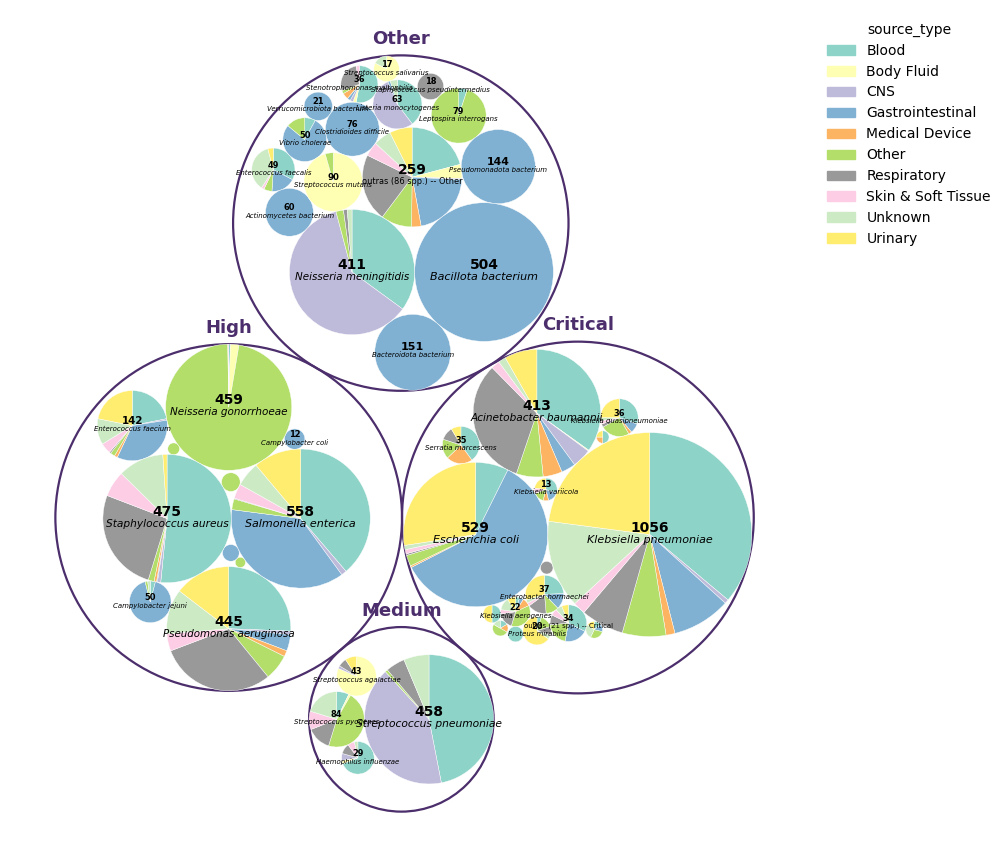

In [8]:
TOP_N_ESPECIES = 15  # por tier 

palette_source = {"Blood":"#8dd3c7","Body Fluid":"#ffffb3","CNS":"#bebada",
                   "Gastrointestinal":"#80b1d3","Medical Device":"#fdb462","Other":"#b3de69",
                   "Respiratory":"#999999","Skin & Soft Tissue":"#fccde5","Unknown":"#ccebc5",
                   "Urinary":"#ffed6f"}

ordem_tiers = ["Critical", "High", "Medium", "Other"]

# rótulo de exibição: mantém o nome da espécie se ela estiver no top N do
# PRÓPRIO tier; senão vira "outras (N spp.) -- <tier>" -- a tag de tier no
# nome evita que o bucket "outras" de tiers diferentes se misture no
# crosstab de source_type logo abaixo (senão colidiria como se fosse 1 só)
metadata_bolha = metadata.copy()
metadata_bolha["especie_bolha"] = metadata_bolha["Species"]
for tier in ordem_tiers:
    contagem_tier = metadata_bolha.loc[metadata_bolha["WHO_Priority"] == tier, "Species"].value_counts()
    fora_do_top = set(contagem_tier.index[TOP_N_ESPECIES:])
    if fora_do_top:
        mask = (metadata_bolha["WHO_Priority"] == tier) & metadata_bolha["Species"].isin(fora_do_top)
        metadata_bolha.loc[mask, "especie_bolha"] = f"outras ({len(fora_do_top)} spp.) -- {tier}"

# hierarquia tier -> espécie (ou "outras"), ORDENADA DESC nos dois níveis
hierarquia = []
for tier in ordem_tiers:
    sub = metadata_bolha[metadata_bolha["WHO_Priority"] == tier]
    especies = sub["especie_bolha"].value_counts()
    hierarquia.append({"id": tier, "datum": especies.sum(),
                        "children": [{"id": sp, "datum": n} for sp, n in especies.items()]})
hierarquia.sort(key=lambda d: -d["datum"])

circles = circlify.circlify(hierarquia, show_enclosure=False, target_enclosure=circlify.Circle(x=0, y=0, r=1))
tier_circles = [c for c in circles if c.level == 1]
especie_circles = [c for c in circles if c.level == 2]

# % de source_type por "bolha" (espécie individual ou grupo "outras")
dist_source = pd.crosstab(metadata_bolha["especie_bolha"], metadata_bolha["source_type"], normalize="index")

fig, ax = plt.subplots(figsize=(14, 11))
ax.set_aspect("equal")
ax.axis("off")

for c in tier_circles:
    ax.add_patch(plt.Circle((c.x, c.y), c.r, fill=False, edgecolor="#4b2e6b", linewidth=1.6, zorder=1))
    ax.text(c.x, c.y + c.r + 0.02, c.ex["id"], ha="center", va="bottom",
            fontsize=13, fontweight="bold", color="#4b2e6b")

for c in especie_circles:
    sp, n = c.ex["id"], c.ex["datum"]
    fracoes = dist_source.loc[sp]
    fracoes = fracoes[fracoes > 0]
    start = 90.0
    for src, frac in fracoes.items():
        theta = 360 * frac
        end = start - theta
        ax.add_patch(mpatches.Wedge((c.x, c.y), c.r, end, start, facecolor=palette_source[src],
                                     edgecolor="white", linewidth=0.3, zorder=2))
        start = end
    # limiar de raio mais alto que na versão do PR -- com muito mais bolha
    # competindo por espaço, o raio médio cai bastante; sem isso vira sopa de letra
    if c.r > 0.025:
        eh_agregado = sp.startswith("outras (")
        ax.text(c.x, c.y, str(n), ha="center", va="bottom",
                fontsize=min(10, max(6, c.r * 80)), fontweight="bold", zorder=3)
        ax.text(c.x, c.y, sp, ha="center", va="top",
                fontsize=max(5, min(8, c.r * 45)),
                style="normal" if eh_agregado else "italic", zorder=3)

handles = [mpatches.Patch(color=palette_source[s], label=s) for s in palette_source]
ax.legend(handles=handles, title="source_type", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

todos = tier_circles + especie_circles
ax.set_xlim(min(c.x - c.r for c in todos) - 0.12, max(c.x + c.r for c in todos) + 0.12)
ax.set_ylim(min(c.y - c.r for c in todos) - 0.12, max(c.y + c.r for c in todos) + 0.12)

In [11]:
fig.savefig("../data/images/bubble_plot.png", bbox_inches="tight", dpi=300)

## Por ano

In [17]:
ordem_who = ["Other", "Medium", "High", "Critical"]
cores_who = {"Critical": "#7f0000", "High": "#e34a33", "Medium": "#fdbb84", "Other": "#bdbdbd"}

dados_ano = metadata.dropna(subset=["Date"]).copy()
dados_ano["Ano"] = dados_ano["Date"].astype(int)

dados_ano.head()

,Species,Source,Date,Location,sample,BioSample,Estado,Região,source_type,WHO_Priority,Ano
1,Escherichia coli,NaN,1990.0,Brazil,GCA_000316425.1,SAMN01041333,NaN,NaN,Unknown,Critical,1990
2,Vibrio cholerae,patient with cholera-like diarrhea,1991.0,NaN,GCA_000223095.2,SAMN02470783,NaN,NaN,Gastrointestinal,Other,1991
3,Acinetobacter bereziniae,Rectal Swab,2019.0,Brazil,GCA_036761135.1,SAMN39408214,NaN,NaN,Gastrointestinal,Other,2019
4,Acinetobacter bereziniae,Endotracheal aspirate,2014.0,"Londrina, PR",GCA_003670255.1,SAMN09907131,PR,Sul,Respiratory,Other,2014
5,Acinetobacter bereziniae,blood,2013.0,"Sao Paulo, Botucatu",GCA_006334885.1,SAMN10963611,SP,Sul,Blood,Other,2013


In [18]:
tabela_ano_who = pd.crosstab(dados_ano["Ano"], dados_ano["WHO_Priority"])
tabela_ano_who = tabela_ano_who[[c for c in ordem_who if c in tabela_ano_who.columns]]

tabela_ano_who.head()

WHO_Priority,Other,Medium,High,Critical
Ano,,,,
1909,1,0,0,0
1960,0,0,1,0
1961,1,0,0,0
1968,0,0,1,0
1969,0,0,1,0


215 genomas sem ano registrado (excluídos do gráfico)


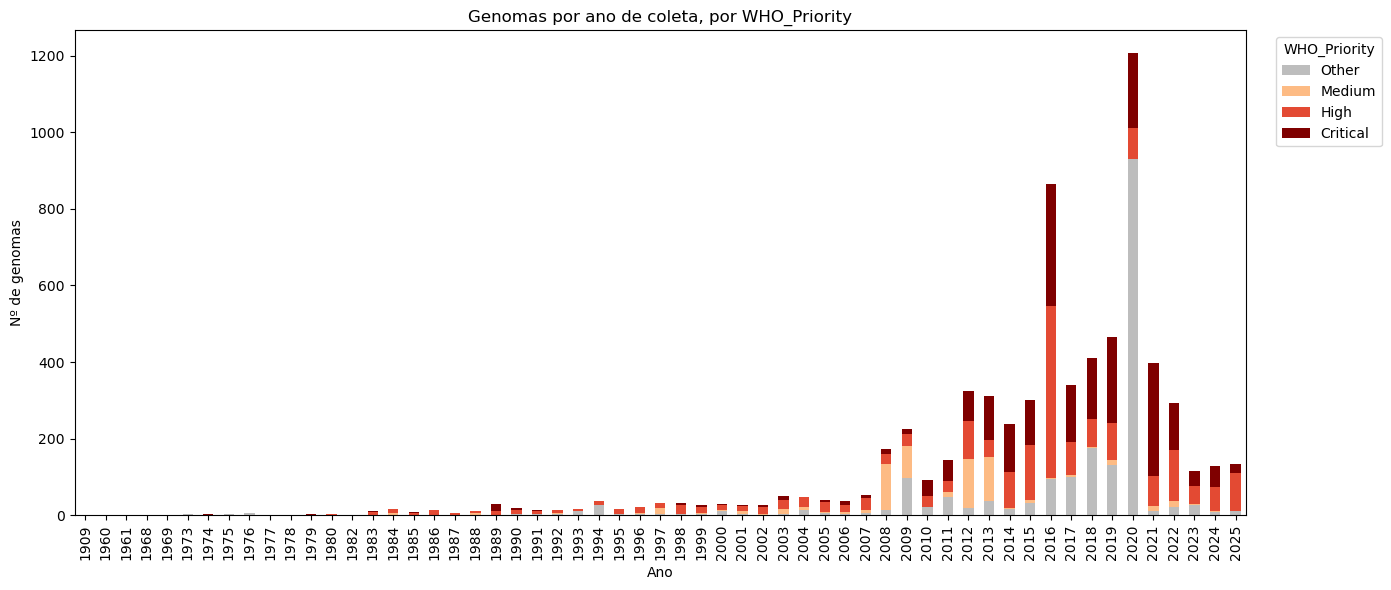

In [19]:
fig, ax = plt.subplots(figsize=(14, 6))
tabela_ano_who.plot(kind="bar", stacked=True, ax=ax, color=[cores_who[c] for c in tabela_ano_who.columns])
ax.set_xlabel("Ano")
ax.set_ylabel("Nº de genomas")
ax.set_title("Genomas por ano de coleta, por WHO_Priority")
ax.legend(title="WHO_Priority", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

print(f"{metadata['Date'].isna().sum()} genomas sem ano registrado (excluídos do gráfico)")

## Por região

In [22]:
dados_regiao = metadata.dropna(subset=["Região"]).copy()
tabela_regiao_who = pd.crosstab(dados_regiao["Região"], dados_regiao["WHO_Priority"])
tabela_regiao_who = tabela_regiao_who[[c for c in ordem_who if c in tabela_regiao_who.columns]]
tabela_regiao_who = tabela_regiao_who.loc[tabela_regiao_who.sum(axis=1).sort_values(ascending=False).index]

tabela_regiao_who.head()

WHO_Priority,Other,Medium,High,Critical
Região,,,,
Sul,712,40,652,1006
Sudeste,117,27,265,171
Nordeste,396,13,47,85
Norte,338,0,34,55
Centro-oeste,171,5,21,11


2865 genomas sem região registrada (excluídos)


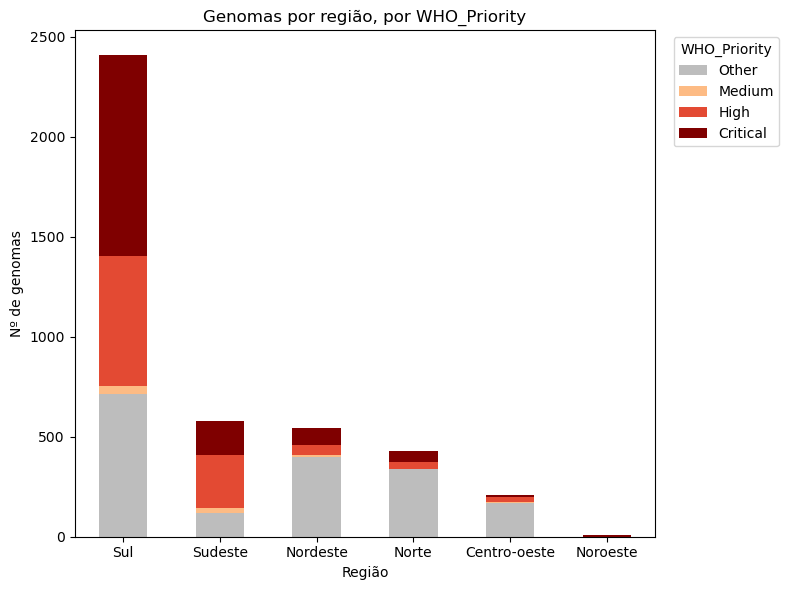

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
tabela_regiao_who.plot(kind="bar", stacked=True, ax=ax, color=[cores_who[c] for c in tabela_regiao_who.columns])
ax.set_xlabel("Região")
ax.set_ylabel("Nº de genomas")
ax.set_title("Genomas por região, por WHO_Priority")
ax.legend(title="WHO_Priority", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()

print(f"{metadata['Região'].isna().sum()} genomas sem região registrada (excluídos)")